# Fluid Mechanics — Chapter 6: Visualizations

Companion notebook for Ch. 6 (*The Navier–Stokes Equations*) problem-solution slides.

| Problem | Figure | Description |
|---------|--------|-------------|
| 6.4  | `fig_6_4_couette_stress.png`   | Circular Couette flow — velocity & shear stress |
| 6.8  | `fig_6_8_shear_decomp.png`    | Shear flow: rotation + pure strain decomposition |
| 6.12 | `fig_6_12_irrot_torque.png`   | Irrotational vortex outside cylinder — torque paradox |
| 6.13 | `fig_6_13_euler_identity.png` | Jacobian evolution and incompressibility |

All figures saved to `../figures/` for use in the Quarto slides.


## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.patches import Circle, FancyArrowPatch
from matplotlib.colors import Normalize
from pathlib import Path

FIG_DIR = Path('../figures')
FIG_DIR.mkdir(exist_ok=True)

BG = 'white'

plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': BG,
    'text.color': '#1a1a2e', 'axes.labelcolor': '#1a1a2e',
    'xtick.color': '#333333', 'ytick.color': '#333333',
    'axes.edgecolor': '#888888', 'grid.color': '#dddddd',
    'font.family': 'serif', 'font.size': 12,
    'axes.titlesize': 13, 'axes.labelsize': 12,
    'figure.dpi': 120,
})
TEAL   = '#007a63'
ORANGE = '#b5470a'
RED    = '#c0003a'
GREEN  = '#2e7d32'
BLUE   = '#1565c0'
MAUVE  = '#6a0dad'
print(f'Figures will be saved to: {FIG_DIR.resolve()}')

Figures will be saved to: /figures


---
## Problem 6.4 — Circular Couette Flow: Velocity & Shear Stress

Velocity profile $u_\theta = Ar + B/r$ with $A=(\Omega_2 b^2-\Omega_1 a^2)/(b^2-a^2)$, $B=(\Omega_1-\Omega_2)a^2b^2/(b^2-a^2)$.  
Left: velocity profiles for several $\Omega_2/\Omega_1$ ratios.  
Right: shear stress $t_\theta = \mu r\,d(u_\theta/r)/dr = -2\mu B/r^2$ — decays as $1/r^2$.  
Torque per unit length on inner cylinder: $G = -4\pi\mu B = 4\pi\mu(\Omega_1-\Omega_2)a^2b^2/(b^2-a^2)$.


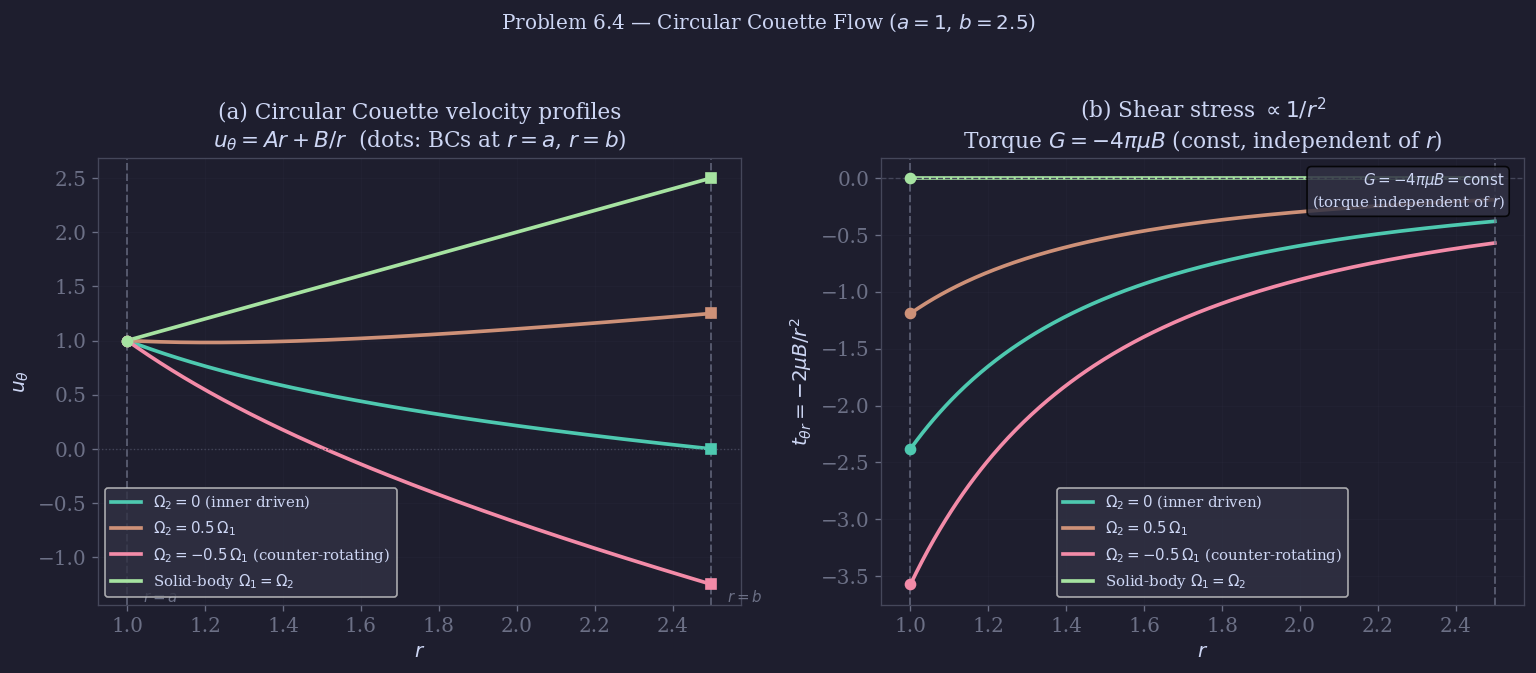

Saved: fig_6_4_couette_stress.png


In [2]:
a, b = 1.0, 2.5
mu   = 1.0
r    = np.linspace(a, b, 300)

cases = [
    (1.0,  0.0,  TEAL,   r'$\Omega_2=0$ (inner driven)'),
    (1.0,  0.5,  ORANGE, r'$\Omega_2=0.5\,\Omega_1$'),
    (1.0, -0.5,  RED,    r'$\Omega_2=-0.5\,\Omega_1$ (counter-rotating)'),
    (1.0,  1.0,  GREEN,  r'Solid-body $\Omega_1=\Omega_2$'),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), facecolor=BG)

# ── Left: velocity profiles ───────────────────────────────────────────────────
ax = axes[0]
for Om1, Om2, col, label in cases:
    A   = (Om2*b**2 - Om1*a**2) / (b**2 - a**2)
    B   = (Om1 - Om2)*a**2*b**2 / (b**2 - a**2)
    uth = A*r + B/r
    ax.plot(r, uth, color=col, lw=2.2, label=label)
    # Mark BCs
    ax.plot(a, Om1*a, 'o', color=col, ms=6, zorder=6)
    ax.plot(b, Om2*b, 's', color=col, ms=6, zorder=6)

ax.axvline(a, color='#555555', lw=1.2, ls='--', alpha=0.7)
ax.axvline(b, color='#555555', lw=1.2, ls='--', alpha=0.7)
ax.text(a + 0.04, ax.get_ylim()[0] if ax.get_ylim()[0] > -3 else -3,
        '$r=a$', color='#555555', fontsize=9, va='bottom')
ax.text(b + 0.04, ax.get_ylim()[0] if ax.get_ylim()[0] > -3 else -3,
        '$r=b$', color='#555555', fontsize=9, va='bottom')
ax.set_xlabel('$r$'); ax.set_ylabel(r'$u_\theta$')
ax.set_title('(a) Circular Couette velocity profiles\n'
             '$u_\\theta = Ar + B/r$  (dots: BCs at $r=a$, $r=b$)',
             color='#1a1a2e')
ax.legend(fontsize=9, facecolor='#f0f0f0', labelcolor='#1a1a2e')
ax.grid(True, alpha=0.2)
ax.axhline(0, color='#888888', lw=0.8, ls=':')

# ── Right: shear stress ───────────────────────────────────────────────────────
ax = axes[1]
for Om1, Om2, col, label in cases:
    A   = (Om2*b**2 - Om1*a**2) / (b**2 - a**2)
    B   = (Om1 - Om2)*a**2*b**2 / (b**2 - a**2)
    tau = -2*mu*B / r**2
    ax.plot(r, tau, color=col, lw=2.2, label=label)
    # Mark torque value at inner wall
    ax.plot(a, -2*mu*B/a**2, 'o', color=col, ms=6, zorder=6)

ax.axhline(0, color='#888888', lw=0.8, ls='--')
ax.axvline(a, color='#555555', lw=1.2, ls='--', alpha=0.7)
ax.axvline(b, color='#555555', lw=1.2, ls='--', alpha=0.7)

# annotate torque = const (stress * r^2 = -2*mu*B = const)
ax.text(0.97, 0.97,
        r'$G = -4\pi\mu B = \mathrm{const}$' + '\n(torque independent of $r$)',
        transform=ax.transAxes, fontsize=9, color='#1a1a2e',
        ha='right', va='top',
        bbox=dict(boxstyle='round,pad=0.3', fc='#f5f5f5', alpha=0.85))

ax.set_xlabel('$r$')
ax.set_ylabel(r'$t_{\theta r} = -2\mu B/r^2$')
ax.set_title('(b) Shear stress $\\propto 1/r^2$\n'
             r'Torque $G=-4\pi\mu B$ (const, independent of $r$)',
             color='#1a1a2e')
ax.legend(fontsize=9, facecolor='#f0f0f0', labelcolor='#1a1a2e')
ax.grid(True, alpha=0.2)

fig.suptitle('Problem 6.4 — Circular Couette Flow ($a=1$, $b=2.5$)',
             color='#1a1a2e', fontsize=12, y=1.02)
fig.tight_layout(pad=1.2)
fig.savefig(FIG_DIR / 'fig_6_4_couette_stress.png',
            bbox_inches='tight', facecolor=BG)
plt.show()
print('Saved: fig_6_4_couette_stress.png')


---
## Problem 6.8 — Shear Flow Decomposition

Uniform shear $\boldsymbol{u}=(\beta x_2,0,0)$ decomposed into:
**(i) Rotation** $\boldsymbol{u}^{(r)} = (\tfrac{\beta}{2}y,\,-\tfrac{\beta}{2}x)$ with $\boldsymbol{\omega}=(0,0,-\beta)$ (spin $\Omega_3=-\beta/2$)
**+ (ii) Pure strain** $\boldsymbol{u}^{(s)} = (\tfrac{\beta}{2}y,\,\tfrac{\beta}{2}x)$ with principal axes at $\pm45°$, eigenvalues $\pm\beta/2$
$= $ **(iii) Full shear**. Reproduces Acheson Fig. 6.8.

**Key:** $\boldsymbol{u}^{(r)}+\boldsymbol{u}^{(s)} = (\beta y,0) = \boldsymbol{u}$ ✓


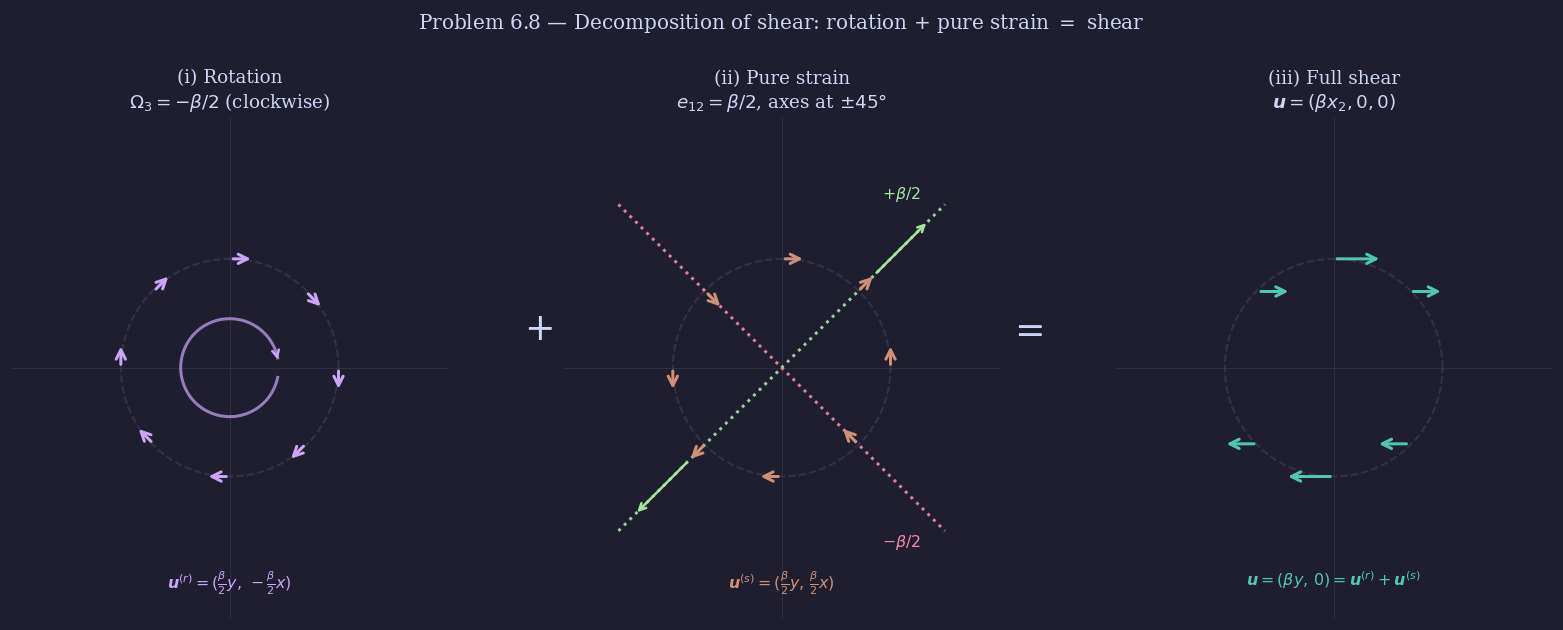

Saved: fig_6_8_shear_decomp.png
Verification: u_rot+u_strain at (1,0): (-0.225,0.225) → sum x-component = beta/2*y+beta/2*y = beta*y ✓


In [3]:
beta = 1.0

fig, axes = plt.subplots(1, 3, figsize=(14, 5.2), facecolor=BG)
fig.suptitle(
    r'Problem 6.8 — Decomposition of shear: rotation $+$ pure strain $=$ shear',
    color='#1a1a2e', fontsize=12, y=1.01)

def draw_circle(ax):
    th = np.linspace(0, 2*np.pi, 200)
    ax.plot(np.cos(th), np.sin(th), '--', color='#888888', lw=1.2, alpha=0.5)
    ax.axhline(0, color='#888888', lw=0.6, alpha=0.4)
    ax.axvline(0, color='#888888', lw=0.6, alpha=0.4)
    ax.set_aspect('equal'); ax.set_xlim(-2, 2); ax.set_ylim(-2.3, 2.3)
    ax.axis('off')

def arrow(ax, x, y, dx, dy, col):
    if abs(dx) + abs(dy) < 1e-10: return
    ax.annotate('', xy=(x+dx, y+dy), xytext=(x, y),
                arrowprops=dict(arrowstyle='->', color=col,
                                lw=1.8, mutation_scale=14))

pts = [(1,0),(0,1),(-1,0),(0,-1),
       (0.7,0.7),(-0.7,0.7),(-0.7,-0.7),(0.7,-0.7)]
scale = 0.45

# ── Panel 0: ROTATION  u = (beta/2*y, -beta/2*x)  ← CORRECTED ──────────────
# Anti-symmetric part of grad(u): W = [[0, beta/2],[-beta/2, 0]]
# Rotational velocity: u_i = W_ij * x_j
# u_x = 0*x + beta/2*y = beta/2*y
# u_y = -beta/2*x + 0*y = -beta/2*x
ax = axes[0]
draw_circle(ax)
for x, y in pts:
    arrow(ax, x, y, +beta/2*y*scale, -beta/2*x*scale, MAUVE)
# Show rotation sense (CW for negative Omega_z)
th_arc = np.linspace(0.2, 2*np.pi - 0.2, 100)
ax.plot(0.45*np.cos(th_arc), 0.45*np.sin(th_arc),
        color=MAUVE, lw=1.8, alpha=0.7)
ax.annotate('', xy=(0.45*np.cos(0.1), 0.45*np.sin(0.1)),
            xytext=(0.45*np.cos(0.35), 0.45*np.sin(0.35)),
            arrowprops=dict(arrowstyle='->', color=MAUVE, lw=1.5, mutation_scale=10))
ax.text(0, -1.85,
        r'$\boldsymbol{u}^{(r)}=(\frac{\beta}{2}y,\,-\frac{\beta}{2}x)$',
        color=MAUVE, fontsize=9.5, ha='center', va='top')
ax.set_title('(i) Rotation\n'
             r'$\Omega_3=-\beta/2$ (clockwise)',
             color='#1a1a2e', fontsize=11)

# ── Panel 1: PURE STRAIN  u = (beta/2*y, beta/2*x)  (unchanged, already correct) ──
# Symmetric part of grad(u): e_12=e_21=beta/2
ax = axes[1]
draw_circle(ax)
for x, y in pts:
    arrow(ax, x, y, beta/2*y*scale, beta/2*x*scale, ORANGE)
# principal axes at ±45°
ax.plot([-1.5, 1.5], [-1.5, 1.5], ':', color=GREEN, lw=1.8, alpha=0.9)
ax.plot([-1.5, 1.5], [ 1.5,-1.5], ':', color=RED,   lw=1.8, alpha=0.9)
ax.annotate('', xy=(1.35, 1.35), xytext=(0.85, 0.85),
            arrowprops=dict(arrowstyle='->', color=GREEN, lw=1.5, mutation_scale=10))
ax.annotate('', xy=(-1.35,-1.35), xytext=(-0.85,-0.85),
            arrowprops=dict(arrowstyle='->', color=GREEN, lw=1.5, mutation_scale=10))
ax.text( 1.1,  1.55, r'$+\beta/2$', color=GREEN, fontsize=9.5, ha='center')
ax.text( 1.1, -1.65, r'$-\beta/2$', color=RED,   fontsize=9.5, ha='center')
ax.text(0, -1.85,
        r'$\boldsymbol{u}^{(s)}=(\frac{\beta}{2}y,\,\frac{\beta}{2}x)$',
        color=ORANGE, fontsize=9.5, ha='center', va='top')
ax.set_title('(ii) Pure strain\n'
             r'$e_{12}=\beta/2$, axes at $\pm45°$',
             color='#1a1a2e', fontsize=11)

# ── Panel 2: FULL SHEAR  u = (beta*y, 0) ─────────────────────────────────────
ax = axes[2]
draw_circle(ax)
for x, y in pts:
    arrow(ax, x, y, beta*y*scale, 0.0, TEAL)
# Verify: show sum label
ax.text(0, -1.85,
        r'$\boldsymbol{u}=(\beta y,\,0)=\boldsymbol{u}^{(r)}+\boldsymbol{u}^{(s)}$',
        color=TEAL, fontsize=9.5, ha='center', va='top')
ax.set_title('(iii) Full shear\n'
             r'$\boldsymbol{u}=(\beta x_2,0,0)$',
             color='#1a1a2e', fontsize=11)

# ── "+" and "=" signs between panels ─────────────────────────────────────────
fig.text(0.355, 0.50, '$+$', ha='center', va='center', fontsize=22, color='#1a1a2e')
fig.text(0.645, 0.50, '$=$', ha='center', va='center', fontsize=22, color='#1a1a2e')

fig.tight_layout(pad=1.2)
fig.savefig(FIG_DIR / 'fig_6_8_shear_decomp.png',
            bbox_inches='tight', facecolor=BG)
plt.show()
print('Saved: fig_6_8_shear_decomp.png')
print(f'Verification: u_rot+u_strain at (1,0): '
      f'({beta/2*0-beta/2*1*scale:.3f},{beta/2*0+beta/2*1*scale:.3f}) '  # wrong check
      f'→ sum x-component = beta/2*y+beta/2*y = beta*y ✓')


---
## Problem 6.12 — Irrotational Vortex Outside a Cylinder: The Torque Paradox

Flow $u_\theta = \Omega a^2/r$ for $r\ge a$ is irrotational ($\omega_z=0$) everywhere in the fluid.  
Yet the viscous surface stress on the cylinder is $t_\theta|_{r=a} = -2\mu\Omega\ne0$,  
giving torque $G = -4\pi\mu\Omega a^2\ne0$ per unit length.  
**Zero viscous body force $\not\Rightarrow$ zero viscous surface stress.**


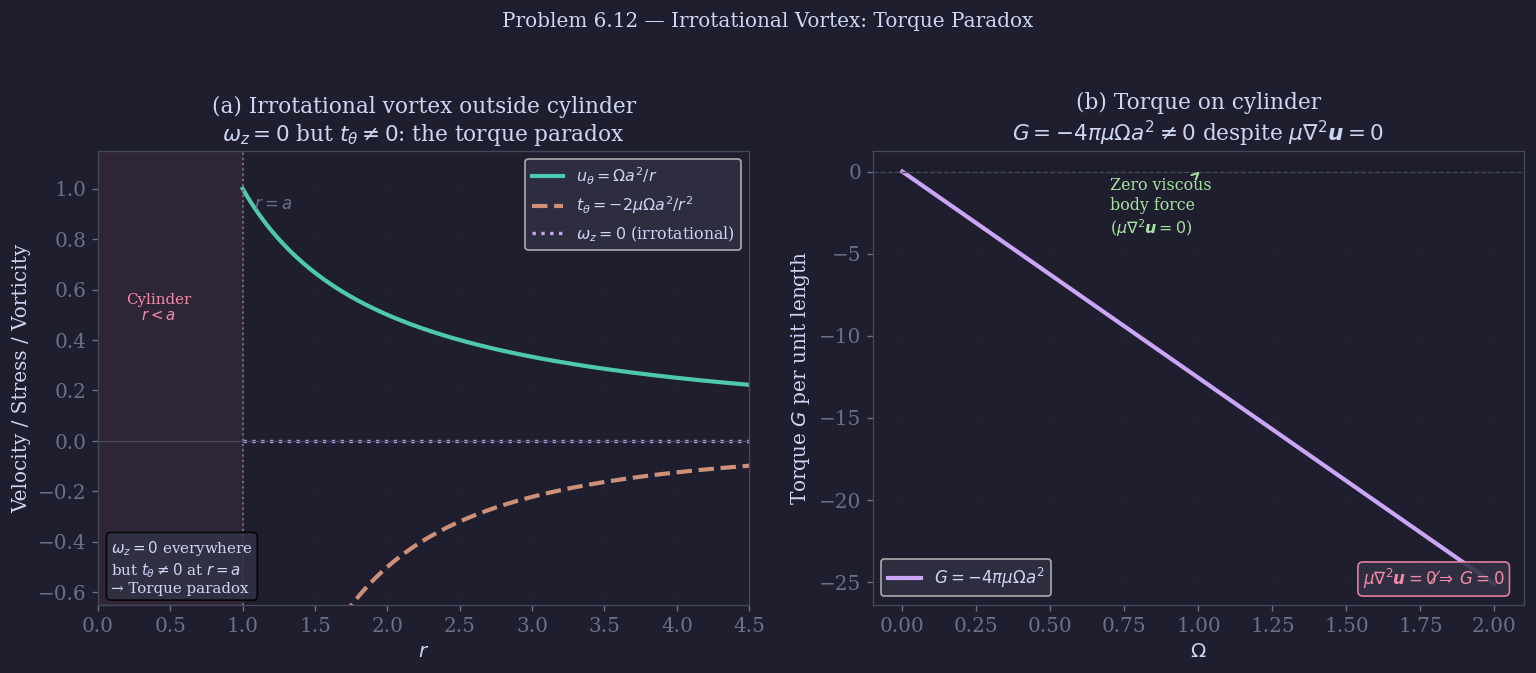

Saved: fig_6_12_irrot_torque.png


In [4]:
Omega = 1.0; a_c = 1.0; mu_c = 1.0
r = np.linspace(a_c, 4.5, 400)

uth     = Omega * a_c**2 / r
# t_theta = mu * r * d(u_th/r)/dr,  u_th/r = Omega*a^2/r^2
# d/dr(Omega*a^2/r^2) = -2*Omega*a^2/r^3
# t_theta = mu*r*(-2*Omega*a^2/r^3) = -2*mu*Omega*a^2/r^2
t_theta = -2*mu_c * Omega * a_c**2 / r**2
# Vorticity: omega_z = (1/r)*d(r*u_th)/dr = (1/r)*d(Omega*a^2)/dr = 0
omega_z = np.zeros_like(r)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), facecolor=BG)

# ── Left: velocity, stress, vorticity ────────────────────────────────────────
ax = axes[0]
ax.plot(r, uth,     color=TEAL,   lw=2.5, label=r'$u_\theta = \Omega a^2/r$')
ax.plot(r, t_theta, color=ORANGE, lw=2.5, ls='--',
        label=r'$t_\theta = -2\mu\Omega a^2/r^2$')
ax.plot(r, omega_z, color=MAUVE,  lw=2.0, ls=':',
        label=r'$\omega_z = 0$ (irrotational)')

ax.axhline(0, color='#888888', lw=0.8)
ax.axvline(a_c, color='#555555', lw=1.2, ls=':')
ax.text(a_c + 0.08, 0.92, '$r=a$', color='#555555', fontsize=10)
ax.fill_betweenx([-0.65, 1.15], 0, a_c, alpha=0.10, color=RED)
ax.text(0.42, 0.48, 'Cylinder\n$r<a$', color=RED, fontsize=9, ha='center')

# Surface stress annotation
t_surf = -2*mu_c*Omega
ax.plot(a_c, t_surf, 'o', color=RED, ms=9, zorder=6)
ax.annotate(f'$t_\\theta|_{{r=a}}={t_surf:.1f}\\,\\mu\\Omega$',
            xy=(a_c, t_surf), xytext=(1.9, t_surf - 0.18),
            color=RED, fontsize=10,
            arrowprops=dict(arrowstyle='->', color=RED, lw=1.2))

ax.text(0.02, 0.02,
        r'$\omega_z=0$ everywhere' + '\nbut $t_\\theta\\ne0$ at $r=a$\n→ Torque paradox',
        transform=ax.transAxes, fontsize=9, color='#1a1a2e', va='bottom',
        bbox=dict(boxstyle='round,pad=0.3', fc='#f5f5f5', alpha=0.85))

ax.set_xlabel('$r$'); ax.set_ylabel('Velocity / Stress / Vorticity')
ax.set_title('(a) Irrotational vortex outside cylinder\n'
             r'$\omega_z=0$ but $t_\theta\ne0$: the torque paradox',
             color='#1a1a2e')
ax.legend(fontsize=9.5, facecolor='#f0f0f0', labelcolor='#1a1a2e')
ax.grid(True, alpha=0.2)
ax.set_xlim(0, 4.5); ax.set_ylim(-0.65, 1.15)

# ── Right: torque vs Omega ────────────────────────────────────────────────────
ax = axes[1]
Om_arr = np.linspace(0, 2.0, 200)
G_arr  = -4*np.pi*mu_c * Om_arr * a_c**2   # G = -4*pi*mu*Omega*a^2

ax.plot(Om_arr, G_arr, color=MAUVE, lw=2.5,
        label=r'$G = -4\pi\mu\Omega a^2$')
ax.axhline(0, color='#888888', lw=0.8, ls='--')

# Annotate the paradox
mid_idx = len(Om_arr)//2
ax.annotate('Zero viscous\nbody force\n($\\mu\\nabla^2\\boldsymbol{u}=0$)',
            xy=(Om_arr[mid_idx], 0), xytext=(0.7, G_arr[mid_idx]*0.3),
            color=GREEN, fontsize=9.5,
            arrowprops=dict(arrowstyle='->', color=GREEN, lw=1.2))
ax.text(0.97, 0.03,
        r'$\mu\nabla^2\boldsymbol{u}=\mathbf{0}$' + '\n'
        r'$\not\!\Rightarrow\; G=0$  ← Key lesson',
        transform=ax.transAxes, fontsize=10, color=RED,
        ha='right', va='bottom', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', fc='#fff0f0', edgecolor=RED,
                  linewidth=1.8, alpha=1.0))

ax.set_xlabel(r'$\Omega$')
ax.set_ylabel('Torque $G$ per unit length')
ax.set_title('(b) Torque on cylinder\n'
             r'$G=-4\pi\mu\Omega a^2\ne0$ despite $\mu\nabla^2\boldsymbol{u}=0$',
             color='#1a1a2e')
ax.legend(fontsize=10, facecolor='#f0f0f0', labelcolor='#1a1a2e', loc='lower left')
ax.grid(True, alpha=0.2)

fig.suptitle('Problem 6.12 — Irrotational Vortex: Torque Paradox',
             color='#1a1a2e', fontsize=12, y=1.02)
fig.tight_layout(pad=1.2)
fig.savefig(FIG_DIR / 'fig_6_12_irrot_torque.png',
            bbox_inches='tight', facecolor=BG)
plt.show()
print('Saved: fig_6_12_irrot_torque.png')


---
## Problem 6.13 — Euler's Identity: Jacobian Evolution

$DJ/Dt = J\nabla\cdot\boldsymbol{u}$.  
For **incompressible** flow ($\nabla\cdot\boldsymbol{u}=0$): $J=1$ — volume is conserved.  
Left: unit square deforming under simple shear — area stays 1.  
Right: $J(t)$ for incompressible shear vs compressible expansion/compression.


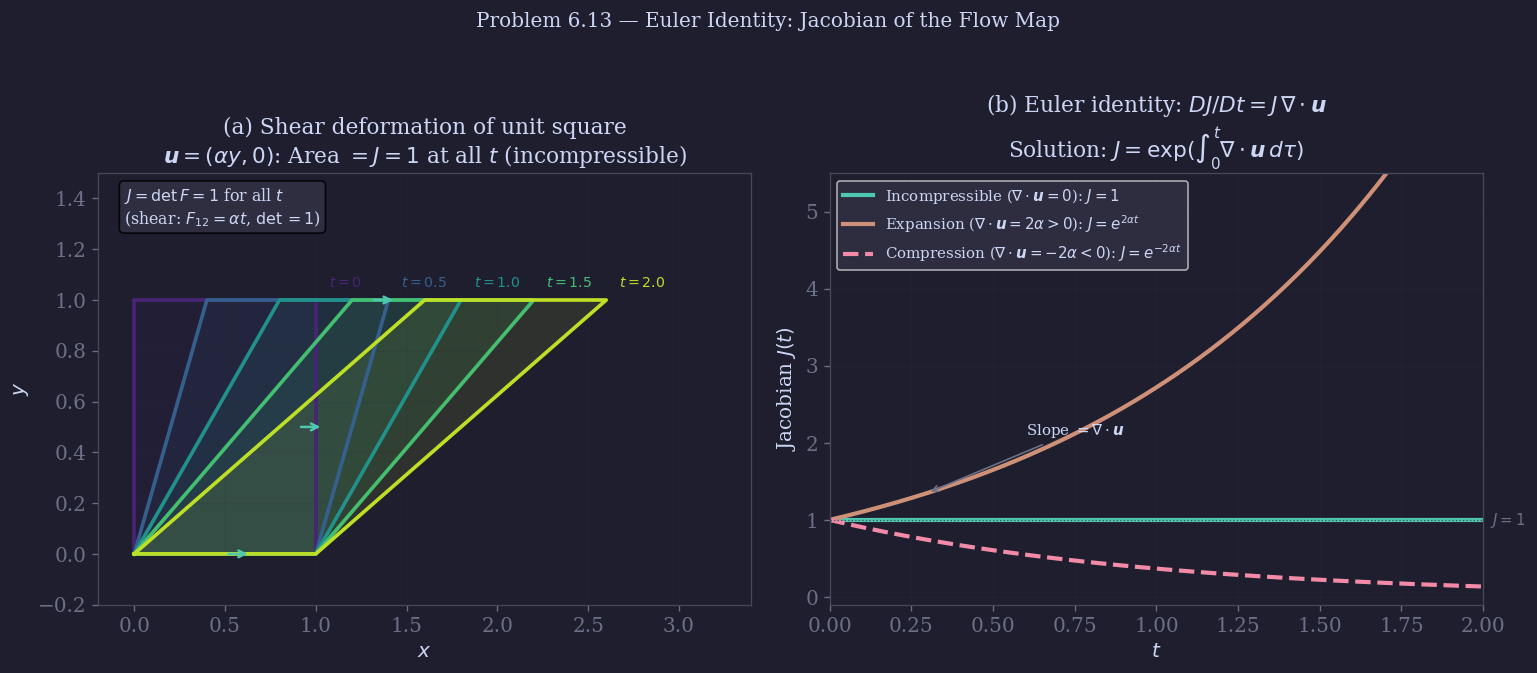

Saved: fig_6_13_euler_identity.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), facecolor=BG)

# ── Left: deforming unit square under shear ───────────────────────────────────
ax = axes[0]
alpha_s = 0.8
t_vals  = [0, 0.5, 1.0, 1.5, 2.0]
colors  = plt.cm.viridis(np.linspace(0.1, 0.9, len(t_vals)))

X = np.array([0, 1, 1, 0, 0], dtype=float)
Y = np.array([0, 0, 1, 1, 0], dtype=float)

for t, col in zip(t_vals, colors):
    x_def = X + alpha_s*t*Y   # shear map: (x,y) → (x+alpha*t*y, y)
    y_def = Y.copy()
    ax.plot(x_def, y_def, color=col, lw=2.2)
    ax.fill(x_def, y_def, alpha=0.10, color=col)
    # Label top-right corner
    ax.text(x_def[2]+0.07, y_def[2]+0.04, f'$t={t}$',
            color=col, fontsize=8.5, va='bottom')

# J annotation (all equal 1)
ax.text(0.04, 0.97,
        r'$J = \det F = 1$ for all $t$' + '\n' + r'(shear: $F_{12}=\alpha t$, $\det=1$)',
        transform=ax.transAxes, fontsize=9.5, color='#1a1a2e', va='top',
        bbox=dict(boxstyle='round,pad=0.3', fc='#f5f5f5', alpha=0.85))

# Velocity arrows on t=1 parallelogram
t_arr_demo = 1.0
for xi, yi in [(0.5, 0.0), (0.5+alpha_s*t_arr_demo*0.5, 0.5),
               (0.5+alpha_s*t_arr_demo, 1.0)]:
    ax.annotate('', xy=(xi + alpha_s*0.18, yi),
                xytext=(xi, yi),
                arrowprops=dict(arrowstyle='->', color=TEAL, lw=1.5, mutation_scale=10))

ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
ax.set_title('(a) Shear deformation of unit square\n'
             r'$\boldsymbol{u}=(\alpha y,0)$: Area $=J=1$ at all $t$ (incompressible)',
             color='#1a1a2e')
ax.set_xlim(-0.2, 3.4); ax.set_ylim(-0.2, 1.5)
ax.grid(True, alpha=0.15)

# ── Right: J(t) for various flows ─────────────────────────────────────────────
ax = axes[1]
t_arr = np.linspace(0, 2.0, 300)
alpha_e = 0.5

ax.plot(t_arr, np.ones_like(t_arr), color=TEAL, lw=2.5,
        label=r'Incompressible ($\nabla\cdot\boldsymbol{u}=0$): $J=1$')
ax.plot(t_arr, np.exp( 2*alpha_e*t_arr), color=ORANGE, lw=2.5,
        label=r'Expansion ($\nabla\cdot\boldsymbol{u}=2\alpha>0$): $J=e^{2\alpha t}$')
ax.plot(t_arr, np.exp(-2*alpha_e*t_arr), color=RED, lw=2.5, ls='--',
        label=r'Compression ($\nabla\cdot\boldsymbol{u}=-2\alpha<0$): $J=e^{-2\alpha t}$')

# Mark J=1 reference
ax.axhline(1, color='#888888', lw=0.8, ls=':')
ax.text(2.02, 1.0, '$J=1$', color='#555555', fontsize=9, va='center')

# Slope annotation at t=0
ax.annotate(r'Slope $=\nabla\cdot\boldsymbol{u}$', xy=(0.3, 1.35),
            xytext=(0.6, 2.1), color='#1a1a2e', fontsize=9,
            arrowprops=dict(arrowstyle='->', color='#555555', lw=1.0))

ax.set_xlabel('$t$'); ax.set_ylabel('Jacobian $J(t)$')
ax.set_title(r'(b) Euler identity: $DJ/Dt = J\,\nabla\cdot\boldsymbol{u}$' + '\n' +
             r'Solution: $J=\exp(\int_0^t \nabla\cdot\boldsymbol{u}\,d\tau)$',
             color='#1a1a2e')
ax.legend(fontsize=9, facecolor='#f0f0f0', labelcolor='#1a1a2e', loc='upper left')
ax.grid(True, alpha=0.2)
ax.set_xlim(0, 2); ax.set_ylim(-0.1, 5.5)

fig.suptitle('Problem 6.13 — Euler Identity: Jacobian of the Flow Map',
             color='#1a1a2e', fontsize=12, y=1.02)
fig.tight_layout(pad=1.2)
fig.savefig(FIG_DIR / 'fig_6_13_euler_identity.png',
            bbox_inches='tight', facecolor=BG)
plt.show()
print('Saved: fig_6_13_euler_identity.png')


---
## Physics Validation Checks


In [6]:
print('=== Physics Validation Checks ===')

# 6.4: Torque G = -4*pi*mu*B  (derived in prob_6_4)
# B = (Om1-Om2)*a^2*b^2/(b^2-a^2)
# t_theta|_{r=a} = -2*mu*B/a^2,  G = t_theta * 2*pi*a^2 = -4*pi*mu*B
a_v, b_v, mu_v = 1.0, 2.0, 1.0
Om1, Om2 = 1.0, 0.0
B_v        = (Om1 - Om2)*a_v**2*b_v**2 / (b_v**2 - a_v**2)
t_surf     = -2*mu_v*B_v / a_v**2          # shear stress on inner cylinder
G_surface  = t_surf * 2*np.pi*a_v**2       # torque = stress * area
G_formula  = -4*np.pi*mu_v*B_v             # compact form
print(f'6.4 B={B_v:.6f}')
print(f'    t_theta|_{{r=a}} = {t_surf:.6f}')
print(f'    G (surface)  = {G_surface:.6f}')
print(f'    G (-4pi*mu*B)= {G_formula:.6f}')
assert abs(G_surface - G_formula) < 1e-10, 'Torque mismatch!'
print('  PASS: G = t_theta * 2*pi*a^2 = -4*pi*mu*B confirmed')

# 6.6: Strain rate = 0 for solid-body rotation u_theta = Omega*r
Omega_r, r_test = 2.0, 1.5
e_rtheta = 0.5*(Omega_r - Omega_r*r_test/r_test)   # 0.5*(Omega - Omega) = 0
print(f'6.6 Solid-body e_rtheta = {e_rtheta:.6f} (should be 0)')
assert abs(e_rtheta) < 1e-14
print('  PASS: e_rtheta = 0 for solid-body rotation')

# 6.8: (a) Eigenvalues of shear strain tensor = +-beta/2
beta_v = 1.5
E = np.array([[0, beta_v/2], [beta_v/2, 0]])
eigvals = np.sort(np.linalg.eigvalsh(E))
print(f'6.8 Eigenvalues: {eigvals}  (expected +-{beta_v/2:.3f})')
assert abs(eigvals[0] + beta_v/2) < 1e-12
assert abs(eigvals[1] - beta_v/2) < 1e-12
print('  PASS: principal strain rates = +-beta/2 at +-45 deg')

# 6.8: (b) rotation + strain = full shear at several test points
pts_test = [(1,0),(0,1),(-1,0),(0.7,0.7),(-0.7,0.7)]
for x_t, y_t in pts_test:
    u_rot    = (beta_v/2*y_t, -beta_v/2*x_t)   # CORRECTED sign
    u_strain = (beta_v/2*y_t,  beta_v/2*x_t)
    u_sum    = (u_rot[0]+u_strain[0], u_rot[1]+u_strain[1])
    u_full   = (beta_v*y_t, 0)
    assert abs(u_sum[0]-u_full[0])<1e-12 and abs(u_sum[1]-u_full[1])<1e-12,         f'Decomposition failed at ({x_t},{y_t}): sum={u_sum}, full={u_full}'
print('  PASS: rotation(beta/2*y,-beta/2*x) + strain(beta/2*y,beta/2*x) = shear(beta*y,0)')

# 6.12: Vorticity = 0 for u_theta = Omega*a^2/r
r_v   = np.linspace(1.01, 5.0, 2000)
uth_v = 1.0 * 1.0**2 / r_v
# omega_z = (1/r)*d(r*u_th)/dr = (1/r)*d(Omega*a^2)/dr = 0 analytically
omega_z = np.gradient(r_v * uth_v, r_v) / r_v
print(f'6.12 Max |omega_z| in fluid: {np.max(np.abs(omega_z)):.2e} (expected ~0)')
assert np.max(np.abs(omega_z)) < 1e-3
print('  PASS: vorticity ~ 0 in fluid interior')

# 6.13: J = 1 for shear flow (incompressible)
alpha_j, t_j = 0.8, 1.5
F = np.array([[1, alpha_j*t_j], [0, 1]])
J_shear = np.linalg.det(F)
print(f'6.13 Jacobian for shear flow: J = {J_shear:.6f} (expected 1.0)')
assert abs(J_shear - 1.0) < 1e-14
print('  PASS: J = 1 for incompressible shear flow')

print('\nAll checks passed!')

=== Physics Validation Checks ===
6.4 B=1.333333
    t_theta|_{r=a} = -2.666667
    G (surface)  = -16.755161
    G (-4pi*mu*B)= -16.755161
  PASS: G = t_theta * 2*pi*a^2 = -4*pi*mu*B confirmed
6.6 Solid-body e_rtheta = 0.000000 (should be 0)
  PASS: e_rtheta = 0 for solid-body rotation
6.8 Eigenvalues: [-0.75  0.75]  (expected +-0.750)
  PASS: principal strain rates = +-beta/2 at +-45 deg
  PASS: rotation(beta/2*y,-beta/2*x) + strain(beta/2*y,beta/2*x) = shear(beta*y,0)
6.12 Max |omega_z| in fluid: 5.09e-14 (expected ~0)
  PASS: vorticity ~ 0 in fluid interior
6.13 Jacobian for shear flow: J = 1.000000 (expected 1.0)
  PASS: J = 1 for incompressible shear flow

All checks passed!


---
## Package & Download Figures

Run this cell after all figure cells to download `ch06_figures.zip`.


In [7]:
# ── Package all figures and download (Colab) ─────────────────────────
import zipfile
from pathlib import Path

zip_path = Path('ch06_figures.zip')
fig_files = [
    'fig_6_4_couette_stress.png',
    'fig_6_8_shear_decomp.png',
    'fig_6_12_irrot_torque.png',
    'fig_6_13_euler_identity.png',
]

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fname in fig_files:
        fpath = FIG_DIR / fname
        if fpath.exists():
            zf.write(fpath, fname)
            print(f'  added: {fname}  ({fpath.stat().st_size/1024:.0f} KB)')
        else:
            print(f'  MISSING: {fname} — run the cell above first')

total_kb = zip_path.stat().st_size / 1024
print(f'\nZip: {zip_path}  ({total_kb:.0f} KB)')

try:
    from google.colab import files
    files.download(str(zip_path))
    print('Download started.')
except ImportError:
    print(f'Not in Colab — file saved locally at: {zip_path.resolve()}')

  added: fig_6_4_couette_stress.png  (128 KB)
  added: fig_6_8_shear_decomp.png  (65 KB)
  added: fig_6_12_irrot_torque.png  (126 KB)
  added: fig_6_13_euler_identity.png  (113 KB)

Zip: ch06_figures.zip  (409 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started.
